In [1]:
!nvidia-smi

Fri Oct  2 07:54:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.178.04             Driver Version: 580.178.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
!git clone https://github.com/timojl/lidere
%cd lidere
!pip install -q timm pillow

Cloning into 'lidere'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 63 (delta 17), reused 57 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 145.81 KiB | 1.78 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/kaggle/working/lidere


In [2]:
!pip install -q -U timm
import timm
print(timm.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 9.7 MB/s eta 0:00:00:00:010:01
1.0.30


In [3]:
!wget -q "https://owncloud.gwdg.de/index.php/s/GahxnxeRKY7ZWWu/download" -O weights.zip
!unzip -q -o weights.zip -d weights
!ls weights

bsds_vitb.pth  camo_vitb.pth  irodent_vitb.pth	pascal_vitb.pth  t10k_vitb.pth


enter block load model...


model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

block load model took 14.1s
freeze backbone
_IncompatibleKeys(missing_keys=['backbone.backbone.cls_token', 'backbone.backbone.reg_token', 'backbone.backbone.patch_embed.proj.weight', 'backbone.backbone.patch_embed.proj.bias', 'backbone.backbone.blocks.0.gamma_1', 'backbone.backbone.blocks.0.gamma_2', 'backbone.backbone.blocks.0.norm1.weight', 'backbone.backbone.blocks.0.norm1.bias', 'backbone.backbone.blocks.0.attn.qkv.weight', 'backbone.backbone.blocks.0.attn.proj.weight', 'backbone.backbone.blocks.0.attn.proj.bias', 'backbone.backbone.blocks.0.norm2.weight', 'backbone.backbone.blocks.0.norm2.bias', 'backbone.backbone.blocks.0.mlp.fc1.weight', 'backbone.backbone.blocks.0.mlp.fc1.bias', 'backbone.backbone.blocks.0.mlp.fc2.weight', 'backbone.backbone.blocks.0.mlp.fc2.bias', 'backbone.backbone.blocks.1.gamma_1', 'backbone.backbone.blocks.1.gamma_2', 'backbone.backbone.blocks.1.norm1.weight', 'backbone.backbone.blocks.1.norm1.bias', 'backbone.backbone.blocks.1.attn.qkv.weight', 'backbone.

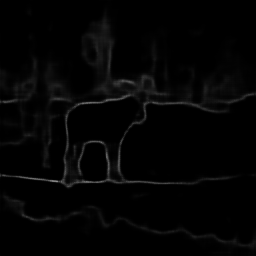

In [4]:
import torch, urllib.request, io
from PIL import Image
from lidere import LiDeRe, TimmBackbone
from torchvision.transforms.functional import to_tensor, to_pil_image

backbone = TimmBackbone(model_name='vit_base_patch16_dinov3.lvd1689m', feat_dim=768, feat_stride=16, img_size=512, cls_token='auto', normalize=True, concat_layers=[3,7,10])
m = LiDeRe(64, 64, backbone, key_name='sem', n_classes=1).cuda()
print(m.load_state_dict(torch.load('weights/bsds_vitb.pth', weights_only=True), strict=False))

with urllib.request.urlopen("https://eckerlab.org/img/example/example2.jpg") as r:
    img = to_tensor(Image.open(io.BytesIO(r.read())).resize((512, 512)))

with torch.no_grad():
    out = m(dict(image=img[None,:,None].cuda()))

contour = to_pil_image(out['sem'][0,0,0].sigmoid().cpu())
contour.save('contour.png')
contour

In [5]:
!wget -q https://eckerlab.org/img/example/{bird.jpg,bird_seg.png,penguins.jpg,penguins_seg.png,sheep.jpg,sheep_seg.png,cow.jpg,cow_seg.png}

from PIL import Image
from lidere.datasets.simple import ImageListDataset
from lidere import LiDeRe, TimmBackbone, SemanticSegmentationTask, train_simple

pairs = []
for name in ['bird', 'penguins', 'sheep', 'cow']:
    pairs += [(Image.open(f"{name}.jpg"), Image.open(f"{name}_seg.png"))]

d = ImageListDataset(pairs, size=(512, 512))
backbone = TimmBackbone(model_name='vit_base_patch16_dinov3.lvd1689m', feat_dim=768, feat_stride=16, img_size=512, cls_token='auto', normalize=True, concat_layers=[3,7,10])
m = LiDeRe(64, 32, backbone, key_name='sem', n_classes=2).cuda()
task = SemanticSegmentationTask(n_classes=2, ignore_index=None)
train_simple(m, d, task, bs=2, n_iter=300)

enter block load model...
block load model took 1.4s
freeze backbone


OSError: Caught OSError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/kaggle/working/lidere/lidere/datasets/simple.py", line 49, in __getitem__
    img = img.convert('RGB')
          ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 986, in convert
    self.load()
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 387, in load
    raise OSError(msg)
OSError: image file is truncated (4 bytes not processed)


In [6]:
import urllib.request, os
from PIL import Image

base = "https://eckerlab.org/img/example/"
names = ['bird', 'penguins', 'sheep', 'cow']

for n in names:
    for suffix in ['.jpg', '_seg.png']:
        fn = n + suffix
        if os.path.exists(fn):
            os.remove(fn)
        urllib.request.urlretrieve(base + fn, fn)
        im = Image.open(fn)
        im.load()
        print(fn, os.path.getsize(fn), "bytes", im.size, im.mode)

bird.jpg 48138 bytes (853, 640) RGB
bird_seg.png 1188 bytes (853, 640) P
penguins.jpg 108229 bytes (739, 640) RGB
penguins_seg.png 1623 bytes (739, 640) P
sheep.jpg 97872 bytes (853, 640) RGB
sheep_seg.png 2088 bytes (853, 640) P
cow.jpg 136466 bytes (852, 640) RGB
cow_seg.png 1878 bytes (852, 640) P


In [7]:
from lidere.datasets.simple import ImageListDataset
from lidere import LiDeRe, TimmBackbone, SemanticSegmentationTask, train_simple

pairs = []
for n in names:
    pairs += [(Image.open(f"{n}.jpg"), Image.open(f"{n}_seg.png"))]

d = ImageListDataset(pairs, size=(512, 512))
backbone = TimmBackbone(model_name='vit_base_patch16_dinov3.lvd1689m', feat_dim=768, feat_stride=16, img_size=512, cls_token='auto', normalize=True, concat_layers=[3,7,10])
m = LiDeRe(64, 32, backbone, key_name='sem', n_classes=2).cuda()
task = SemanticSegmentationTask(n_classes=2, ignore_index=None)
train_simple(m, d, task, bs=2, n_iter=300)

enter block load model...
block load model took 1.0s


KeyboardInterrupt: 

In [8]:
%cd /kaggle/working/lidere
from PIL import Image
from lidere.datasets.simple import ImageListDataset
from lidere import LiDeRe, TimmBackbone, SemanticSegmentationTask, train_simple

names = ['bird', 'penguins', 'sheep', 'cow']
pairs = [(Image.open(f"{n}.jpg"), Image.open(f"{n}_seg.png")) for n in names]

d = ImageListDataset(pairs, size=(512, 512))
backbone = TimmBackbone(model_name='vit_base_patch16_dinov3.lvd1689m', feat_dim=768, feat_stride=16, img_size=512, cls_token='auto', normalize=True, concat_layers=[3,7,10])
m = LiDeRe(64, 32, backbone, key_name='sem', n_classes=2).cuda()
task = SemanticSegmentationTask(n_classes=2, ignore_index=None)
train_simple(m, d, task, bs=2, n_iter=300)

/kaggle/working/lidere
enter block load model...


Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor


block load model took 1.4s
freeze backbone


OSError: Caught OSError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/kaggle/working/lidere/lidere/datasets/simple.py", line 49, in __getitem__
    img = img.convert('RGB')
          ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 986, in convert
    self.load()
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 387, in load
    raise OSError(msg)
OSError: image file is truncated (4 bytes not processed)


In [9]:
%cd /kaggle/working/lidere
from PIL import Image
from lidere.datasets.simple import ImageListDataset
from lidere import LiDeRe, TimmBackbone, SemanticSegmentationTask, train_simple

def load(path):
    with Image.open(path) as im:
        im.load()
        return im.copy()

names = ['bird', 'penguins', 'sheep', 'cow']
pairs = [(load(f"{n}.jpg"), load(f"{n}_seg.png")) for n in names]

d = ImageListDataset(pairs, size=(512, 512))
backbone = TimmBackbone(model_name='vit_base_patch16_dinov3.lvd1689m', feat_dim=768, feat_stride=16, img_size=512, cls_token='auto', normalize=True, concat_layers=[3,7,10])
m = LiDeRe(64, 32, backbone, key_name='sem', n_classes=2).cuda()
task = SemanticSegmentationTask(n_classes=2, ignore_index=None)
train_simple(m, d, task, bs=2, n_iter=300, num_workers=0)

/kaggle/working/lidere
enter block load model...
block load model took 1.4s
freeze backbone


[████████████████████] 300/300 (100.0%)  4.3 it/s  ETA 0s  loss=0.01629


(<lidere.trainers.generic.TrainingLogger at 0x7c5631ee0b30>, None)

In [1]:
import torch
from torchvision.transforms.functional import to_tensor, to_pil_image

m.eval()
img = Image.open('cow.jpg').convert('RGB').resize((512, 512))
x = to_tensor(img)

with torch.no_grad():
    out = m(dict(image=x[None,:,None].cuda()))

pred = out['sem'][0,:,0].argmax(0).cpu().float()
mask = to_pil_image(pred / pred.max().clamp(min=1))
mask.save('cow_pred.png')

# side by side: image and prediction
canvas = Image.new('RGB', (1024, 512))
canvas.paste(img, (0, 0))
canvas.paste(mask.convert('RGB'), (512, 0))
canvas.save('cow_result.png')
canvas

NameError: name 'm' is not defined

Cloning into '/kaggle/working/lidere'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 63 (delta 17), reused 57 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 145.81 KiB | 1.42 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/kaggle/working/lidere
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 10.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 66.4 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.3.0 which is incompatible.
enter block load model...


model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

block load model took 16.3s
freeze backbone


[████████████████████] 300/300 (100.0%)  4.7 it/s  ETA 0s  loss=0.00701


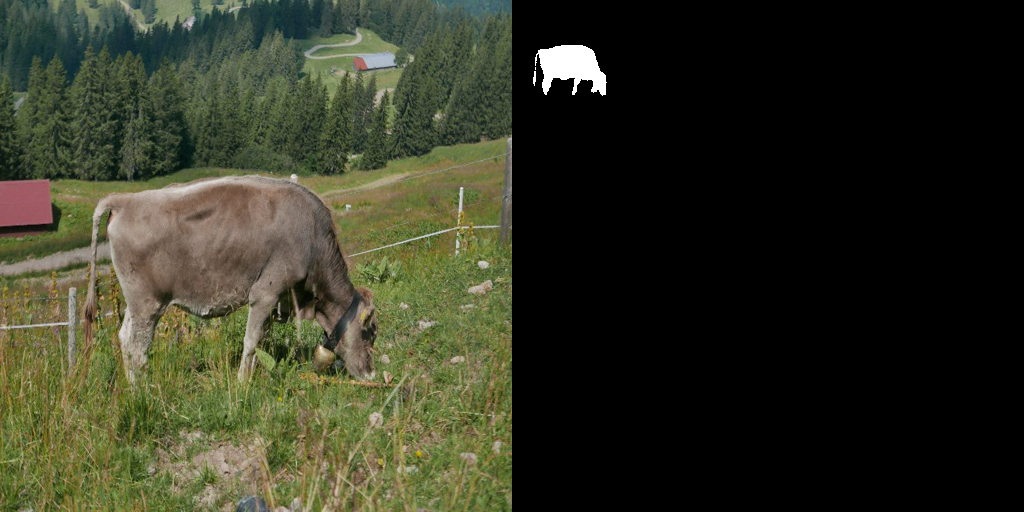

In [2]:
import os
if not os.path.exists('/kaggle/working/lidere'):
    !git clone https://github.com/timojl/lidere /kaggle/working/lidere
%cd /kaggle/working/lidere
!pip install -q -U timm pillow

import urllib.request, torch
from PIL import Image
from torchvision.transforms.functional import to_tensor, to_pil_image
from lidere.datasets.simple import ImageListDataset
from lidere import LiDeRe, TimmBackbone, SemanticSegmentationTask, train_simple

base = "https://eckerlab.org/img/example/"
names = ['bird', 'penguins', 'sheep', 'cow']
for n in names:
    for s in ['.jpg', '_seg.png']:
        if not os.path.exists(n + s):
            urllib.request.urlretrieve(base + n + s, n + s)

def load(p):
    with Image.open(p) as im:
        im.load()
        return im.copy()

pairs = [(load(f"{n}.jpg"), load(f"{n}_seg.png")) for n in names]
d = ImageListDataset(pairs, size=(512, 512))
backbone = TimmBackbone(model_name='vit_base_patch16_dinov3.lvd1689m', feat_dim=768, feat_stride=16, img_size=512, cls_token='auto', normalize=True, concat_layers=[3,7,10])
m = LiDeRe(64, 32, backbone, key_name='sem', n_classes=2).cuda()
task = SemanticSegmentationTask(n_classes=2, ignore_index=None)
train_simple(m, d, task, bs=2, n_iter=300, num_workers=0)

m.eval()
img = load('cow.jpg').convert('RGB').resize((512, 512))
with torch.no_grad():
    out = m(dict(image=to_tensor(img)[None,:,None].cuda()))
pred = out['sem'][0,:,0].argmax(0).cpu().float()
mask = to_pil_image(pred / pred.max().clamp(min=1))
canvas = Image.new('RGB', (1024, 512))
canvas.paste(img, (0, 0))
canvas.paste(mask.convert('RGB'), (512, 0))
canvas.save('cow_result.png')
canvas

raw mask size: torch.Size([128, 128])


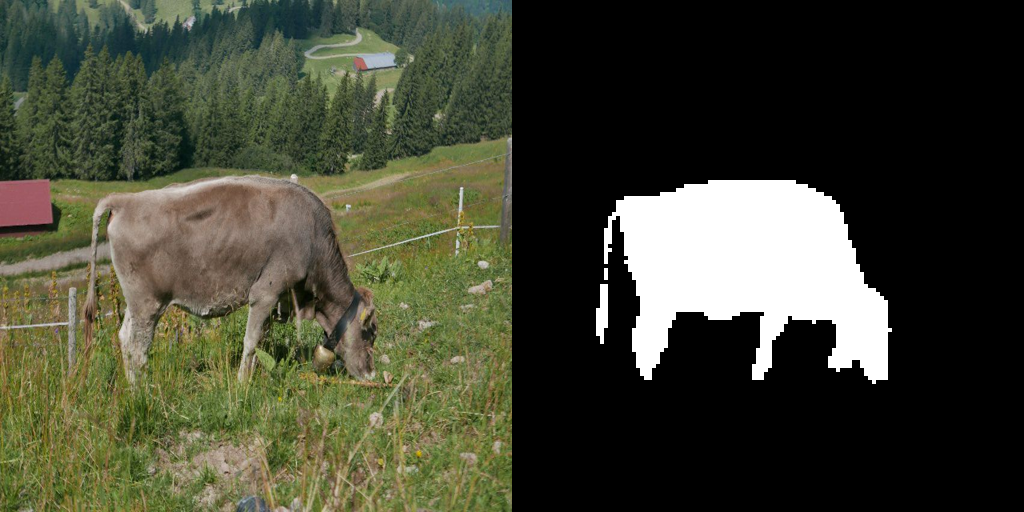

In [3]:
mask_big = to_pil_image(pred / pred.max().clamp(min=1)).resize((512, 512), Image.NEAREST)
print("raw mask size:", pred.shape)

canvas = Image.new('RGB', (1024, 512))
canvas.paste(img, (0, 0))
canvas.paste(mask_big.convert('RGB'), (512, 0))
canvas.save('cow_result.png')
canvas